# Imports

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import ctypes

from numpy import dtype
from pandas.core.dtypes.cast import maybe_downcast_to_dtype

from rust_bridge import MLPRust,TaskMode

lib = ctypes.cdll.LoadLibrary('../lib_classification/target/release/lib_classification.dll')

class MyDroite(ctypes.Structure):_fields_ = [
    ("a", ctypes.c_float),
    ("b", ctypes.c_float),
    ("c", ctypes.c_float),
]

lib.initialisation_droite.restype = ctypes.POINTER(MyDroite)
lib.training.argtypes = [ctypes.c_float, ctypes.c_int32, ctypes.c_int32, MyDroite, ctypes.POINTER(ctypes.c_float), ctypes.POINTER(ctypes.c_float)]
lib.training.restype = ctypes.POINTER(MyDroite)
lib.linear_classification_prediction.restype = ctypes.c_float
lib.linear_classification_prediction.argtypes = [
        ctypes.c_float,
        ctypes.c_float,
        ctypes.c_float,
        ctypes.c_float,
        ctypes.c_float,
        ctypes.c_float
    ]

## Classification

### Linear Simple :
        Linear Model : OK
        MLP (2, 1)   : OK

In [ ]:
X = np.array([
      [1, 1],
      [2, 3],
      [3, 3]
], dtype=np.float32)
Y = np.array([
      1,
      -1,
      -1
], dtype=np.float32)

#### CODE ADDED :

##### MODEL INITIALIZATION

In [ ]:
# ----- LINEAR MODEL -----

ma_droite = lib.initialisation_droite()
a = ma_droite.contents.a
b = ma_droite.contents.b
c = ma_droite.contents.c
w = MyDroite(a, b, c)

data_ptr = X.ctypes.data_as(ctypes.POINTER(ctypes.c_float))

labels_ptr = Y.ctypes.data_as(ctypes.POINTER(ctypes.c_float))

# ----- MLP MODEL -----

mlp = MLPRust(
        layer_sizes=[2,1],
        learning_rate=0.001,
        task_mode=TaskMode.CLASSIFICATION,
    )

##### MODEL TRAINING

In [ ]:
# ----- LINEAR MODEL ----

w = lib.training(ctypes.c_float(0.01), 10000000, len(X), w, data_ptr, labels_ptr)
w = w.contents

# ----- MLP MODEL -----

mlp.fit(X, Y, steps=1000)

##### MODEL PREDICTION

In [ ]:
points_to_predict = []

for i in range(-10,41):
    for j in range(-10,41):
        points_to_predict.append((i/10,j/10))
points_to_predict = np.array(points_to_predict)


# ----- LINEAR MODEL -----

points_to_predict_ = []
predicted_colors = []
for row in range(100):
  for col in range(100):
    point_to_predict = [1.0, row/10.0, col/10.0]
    points_to_predict_.append(point_to_predict)
    predicted_colors.append(
        'lightblue' if lib.linear_classification_prediction(w.a,w.b, w.c, point_to_predict[0] ,point_to_predict[1],point_to_predict[2] ) >= 0 else 'pink')


# ----- MLP MODEL -----

labels = []
colors = []

for p in points_to_predict:
    if mlp.predict_labels(p) == -1:
        labels.append(1.0)
        colors.append('lightblue')
    else:
        labels.append(-1.0)
        colors.append('pink')

#### PLOT CREATION

In [ ]:
# ----- LINEAR MODEL PREDICTED POINTS -----

# plt.scatter(points_to_predict_[:, 1], points_to_predict_[:, 2], c=predicted_colors)

# ----- MLP MODEL PREDICTED POINTS -----
plt.scatter(points_to_predict[:, 0], points_to_predict[:, 1], c=colors)

plt.scatter(X[0, 0], X[0, 1], color='red')
plt.scatter(X[1:3,0], X[1:3,1], color='blue')

plt.xlim(-1, 4)
plt.ylim(-1, 4)
plt.show()
plt.clf()

for i in range(len(X)):
    pred = lib.linear_classification_prediction(w.a, w.b, w.c,1.0, X[i][0], X[i][1])
    print(i, pred, Y[i])

### Linear Multiple :
        Linear Model : OK
        MLP (2, 1)   : OK

In [ ]:
X = np.concatenate(
    [
        np.random.random((50,2)) * 0.9 + np.array([1, 1]), np.random.random((50,2)) * 0.9 + np.array([2, 2])
    ], dtype=np.float32
    )
Y = np.concatenate(
    [
        np.ones((50,1), dtype=np.float32), np.ones((50,1),dtype=np.float32) * -1.0
    ]
    )

#### CODE ADDED :

##### MODEL INITIALIZATION

In [ ]:
# ----- LINEAR MODEL -----

ma_droite1 = lib.initialisation_droite()
a = ma_droite1.contents.a
b = ma_droite1.contents.b
c = ma_droite1.contents.c
w = MyDroite(a, b, c)

data_ptr = X.ctypes.data_as(ctypes.POINTER(ctypes.c_float))

labels_ptr = Y.ctypes.data_as(ctypes.POINTER(ctypes.c_float))

# ----- MLP MODEL -----

try :
    mlp.close()
except:
    pass

mlp = MLPRust(
        layer_sizes=[2,1],
        learning_rate=0.001,
        task_mode=TaskMode.CLASSIFICATION,
    )

##### MODEL TRAINING

In [ ]:
# ----- LINEAR MODEL -----

w = lib.training(ctypes.c_float(0.01), 10000000, len(X), w, data_ptr, labels_ptr)
w = w.contents

# ----- MLP MODEL -----

mlp.fit(X, Y, steps=10000)

##### MODEL PREDICTION

In [ ]:
# ----- LINEAR MODEL -----

points_to_predict_ = []
predicted_colors = []
for row in range(100):
  for col in range(100):
    point_to_predict = [1.0, row/10.0, col/10.0]
    points_to_predict_.append(point_to_predict)
    predicted_colors.append(
        'lightblue' if lib.linear_classification_prediction(w.a,w.b, w.c, point_to_predict[0] ,point_to_predict[1],point_to_predict[2] ) >= 0 else 'pink')
points_to_predict_ = np.array(points_to_predict_)

# ----- MLP MODEL -----

points_to_predict = []

points_to_predict = []

for i in range(100):
    for j in range(100):
        points_to_predict.append((i/10,j/10))
points_to_predict = np.array(points_to_predict)

labels = []
colors = []

for p in points_to_predict:
    if mlp.predict_labels(p) == -1:
        labels.append(1.0)
        colors.append('pink')
    else:
        labels.append(-1.0)
        colors.append('lightblue')

#### PLOT CREATION

In [ ]:
# ----- MLP MODEL PREDICTED POINTS -----
plt.scatter(points_to_predict[:, 0], points_to_predict[:, 1], c=colors)

plt.scatter(X[0:50, 0], X[0:50, 1], color='blue')
plt.scatter(X[50:100,0], X[50:100,1], color='red')
plt.xlim(-1, 4)
plt.ylim(-1, 4)
plt.show()
plt.clf()

### XOR :
        Linear Model    : KO
        MLP (2, 2, 1)   : OK

In [ ]:
X = np.array([[1, 0], [0, 1], [0, 0], [1, 1]])
Y = np.array([1, 1, -1, -1])

#### CODE ADDED :

##### MODEL INITIALIZATION

In [ ]:
# ----- MLP MODEL -----

try :
    mlp.close()
except:
    pass

mlp = MLPRust(
        layer_sizes=[2,2,1],
        learning_rate=0.001,
        task_mode=TaskMode.CLASSIFICATION,
    )

##### MODEL TRAINING

In [ ]:
# ----- MLP MODEL -----

mlp.fit(X, Y, steps=10000)

##### MODEL PREDICTION

In [ ]:
# ----- MLP MODEL -----

points_to_predict = []

for i in range(101):
    for j in range(101):
        points_to_predict.append((i/100,j/100))
points_to_predict = np.array(points_to_predict)

labels = []
colors = []

for p in points_to_predict:
    if mlp.predict_labels(p) == -1:
        labels.append(1.0)
        colors.append('pink')
    else:
        labels.append(-1.0)
        colors.append('lightblue')

#### PLOT CREATION

In [ ]:
# ----- MLP MODEL PREDICTED POINTS -----
plt.scatter(points_to_predict[:, 0], points_to_predict[:, 1], c=colors)

plt.scatter(X[0:2, 0], X[0:2, 1], color='blue')
plt.scatter(X[2:4,0], X[2:4,1], color='red')
plt.show()
plt.clf()

























































































### Cross :
        Linear Model    : KO
        MLP (2, 4, 1)   : OK

In [ ]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X])

#### CODE ADDED :

##### MODEL INITIALIZATION

In [ ]:
# ----- MLP MODEL -----

try :
    mlp.close()
except:
    pass

mlp = MLPRust(
        layer_sizes=[2,4,1],
        learning_rate=0.0001,
        task_mode=TaskMode.CLASSIFICATION,
    )

##### MODEL TRAINING

In [ ]:
# ----- MLP MODEL -----

mlp.fit(X, Y, steps=100000)

##### MODEL PREDICTION

In [ ]:
# ----- MLP MODEL -----

points_to_predict = []

for i in range(-100,100):
    for j in range(-100,100):
        points_to_predict.append((i/100,j/100))
points_to_predict = np.array(points_to_predict)

labels = []
colors = []

for p in points_to_predict:
    if mlp.predict_labels(p) == -1:
        labels.append(1.0)
        colors.append('pink')
    else:
        labels.append(-1.0)
        colors.append('lightblue')

#### PLOT CREATION

In [ ]:
# ----- MLP MODEL PREDICTED POINTS -----
plt.scatter(points_to_predict[:, 0], points_to_predict[:, 1], c=colors)

plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,1], color='red')
plt.show()
plt.clf()

### Multi Linear 3 classes :
        Linear Model x3 : OK
        MLP (2, 3)      : OK

In [ ]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, 1, -1] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, -1, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else
              [-1, -1, -1]for p in X])

X = X[[not np.all(arr == [-1, -1, -1]) for arr in Y]]
Y = Y[[not np.all(arr == [-1, -1, -1]) for arr in Y]]

#### CODE ADDED :

##### MODEL INITIALIZATION

In [ ]:
# ----- MLP MODEL -----

try :
    mlp.close()
except:
    pass

mlp = MLPRust(
        layer_sizes=[2,3],
        learning_rate=0.001,
        task_mode=TaskMode.CLASSIFICATION,
    )

##### MODEL TRAINING

In [ ]:
# ----- MLP MODEL -----

mlp.fit(X, Y, steps=10000)

##### MODEL PREDICTION

In [ ]:
# ----- MLP MODEL -----

points_to_predict = []

for i in range(-100,100):
    for j in range(-100,100):
        points_to_predict.append((i/100,j/100))
points_to_predict = np.array(points_to_predict)

labels = []
colors = []

test = set()

for p in points_to_predict:
    if (mlp.predict_labels(p)[0] == [1,-1,-1]).all():
        labels.append(1.0)
        colors.append('lightblue')
    elif (mlp.predict_labels(p)[0] == [-1,1,-1]).all():
        labels.append(0.0)
        colors.append('pink')
    else:
        labels.append(-1.0)
        colors.append('lightgreen')

#### PLOT CREATION

In [ ]:
# ----- MLP MODEL PREDICTED POINTS -----
plt.scatter(points_to_predict[:, 0], points_to_predict[:, 1], c=colors)

plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

### Multi Cross :
        Linear Model x3 : KO
        MLP (2, ?, ?, 3): OK

In [73]:
X = np.random.random((1000, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25 else [-1, 1, -1] if abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25 else [-1, -1, 1] for p in X])

#### CODE ADDED :

##### MODEL INITIALIZATION

In [74]:
# ----- MLP MODEL -----

try :
    mlp.close()
except:
    pass

mlp = MLPRust(
        layer_sizes=[2,3,3,3],
        learning_rate=0.00001,
        task_mode=TaskMode.CLASSIFICATION,
    )

##### MODEL TRAINING

In [82]:
# ----- MLP MODEL -----

mlp.fit(X, Y, steps=10000000)

##### MODEL PREDICTION

In [87]:
points_to_predict = []

for i in range(-100,100):
    for j in range(-100,100):
        points_to_predict.append((i/100,j/100))
points_to_predict = np.array(points_to_predict)

labels = []
colors = []

# ----- MLP MODEL -----
points_list = []
for p in points_to_predict:
    points_list.append(mlp.predict_labels(p))

points_list = set(points_list)

# for p in points_to_predict:
#     if (mlp.predict_labels(p)[0] == [-1,-1,1]).all():
#         labels.append(1.0)
#         colors.append('lightblue')
#     elif (mlp.predict_labels(p)[0] == [-1,1,-1]).all():
#         labels.append(0.0)
#         colors.append('pink')
#     else:
#         labels.append(-1.0)
#         colors.append('lightgreen')

TypeError: cannot use 'numpy.ndarray' as a set element (unhashable type: 'numpy.ndarray')

#### PLOT CREATION

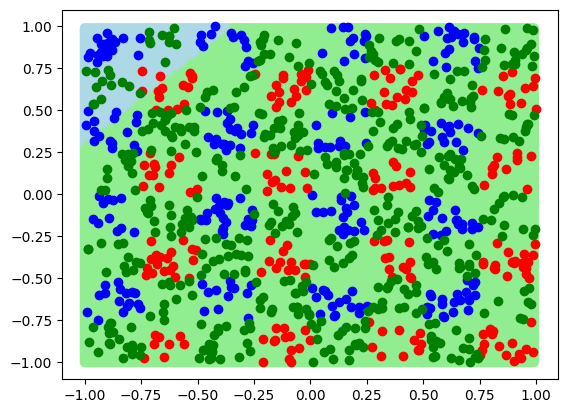

<Figure size 640x480 with 0 Axes>

In [80]:
# ----- MLP MODEL PREDICTED POINTS -----
plt.scatter(points_to_predict[:, 0], points_to_predict[:, 1], c=colors)

plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

## Régression

### Linear Simple 2D :
        Linear Model : OK
        MLP (1, 1)   : OK

In [ ]:
X = np.array([
      [1],
      [2]
], dtype=np.float32)
Y = np.array([
      2,
      3
], dtype=np.float32)

#### CODE ADDED :

##### MODEL INITIALIZATION

#### PLOT CREATION

In [ ]:
# ----- LINEAR MODEL PREDICTED POINTS -----

# plt.scatter(points_to_predict_[:, 1], points_to_predict_[:, 2], c=predicted_colors)

# ----- MLP MODEL PREDICTED POINTS -----
plt.scatter(points_to_predict[:, 0], points_to_predict[:, 1], c=colors)

plt.scatter(X,Y)
plt.show()
plt.clf()

### Non Linear Simple 2D :
        Linear Model    : OK
        MLP (1, ?, 1)   : OK

In [ ]:
X = np.array([
      [1],
      [2],
      [3]
], dtype=np.float32)
Y = np.array([
      2,
      3,
      2.5
], dtype=np.float32)

#### CODE ADDED :

##### MODEL INITIALIZATION

#### PLOT CREATION

In [ ]:
plt.scatter(X,Y)
plt.show()
plt.clf()

### Linear Simple 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

In [ ]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 1]
], dtype=np.float32)
Y = np.array([
      2,
      3,
      2.5
], dtype=np.float32)

#### CODE ADDED :

##### MODEL INITIALIZATION

#### PLOT CREATION

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

### Linear Tricky 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

In [ ]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 3]
], dtype=np.float32)
Y = np.array([
      1,
      2,
      3
], dtype=np.float32)

#### CODE ADDED :

##### MODEL INITIALIZATION

#### PLOT CREATION

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

### Non Linear Simple 3D :
        Linear Model       : KO
        MLP (2, 2, 1)      : OK

In [ ]:
X = np.array([
      [1, 0],
      [0, 1],
      [1, 1],
      [0, 0],
], dtype=np.float32)
Y = np.array([
      2,
      1,
      -2,
      -1
], dtype=np.float32)

#### CODE ADDED :

##### MODEL INITIALIZATION

#### PLOT CREATION

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()